# Garmin Running Activity Analysis
Visualize running metrics from the local SQLite database.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from db import DB_PATH, COLUMNS

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql("SELECT * FROM activities ORDER BY start_time", conn)
conn.close()

df.columns = COLUMNS
df["start_time"] = pd.to_datetime(df["start_time"])
df["distance_km"] = df["distance_m"] / 1000
df["duration_min"] = df["duration_s"] / 60
df["pace_min_km"] = df["duration_min"] / df["distance_km"].replace(0, float("nan"))

print(f"Loaded {len(df)} activities")
df.head()

Loaded 9 activities


,activity_id,name,start_time,distance_m,duration_s,calories,avg_hr,max_hr,avg_speed,elevation_gain,cadence,distance_km,duration_min,pace_min_km
0,21357559646,København Løb terræn,2025-12-26 16:50:51,15018.860352,4346.961914,1268.0,None,None,3.455,59.0,168.21875,15.01886,72.449365,4.823892
1,21400313247,København Løb terræn,2025-12-31 09:58:09,12440.269531,3901.829102,1051.0,None,None,3.188,58.0,163.71875,12.44027,65.030485,5.227418
2,21438058733,København Løb terræn,2026-01-04 09:59:46,13030.110352,4213.988770,1095.0,None,None,3.092,56.0,162.62500,13.03011,70.233146,5.390065
3,21504304381,København Løb terræn,2026-01-10 16:55:57,10647.839844,2915.290039,904.0,None,None,3.652,20.0,166.00000,10.64784,48.588167,4.563195
4,21504309486,København Løb terræn,2026-01-10 17:54:28,1093.229980,391.497986,88.0,None,None,2.792,2.0,161.06250,1.09323,6.524966,5.968521


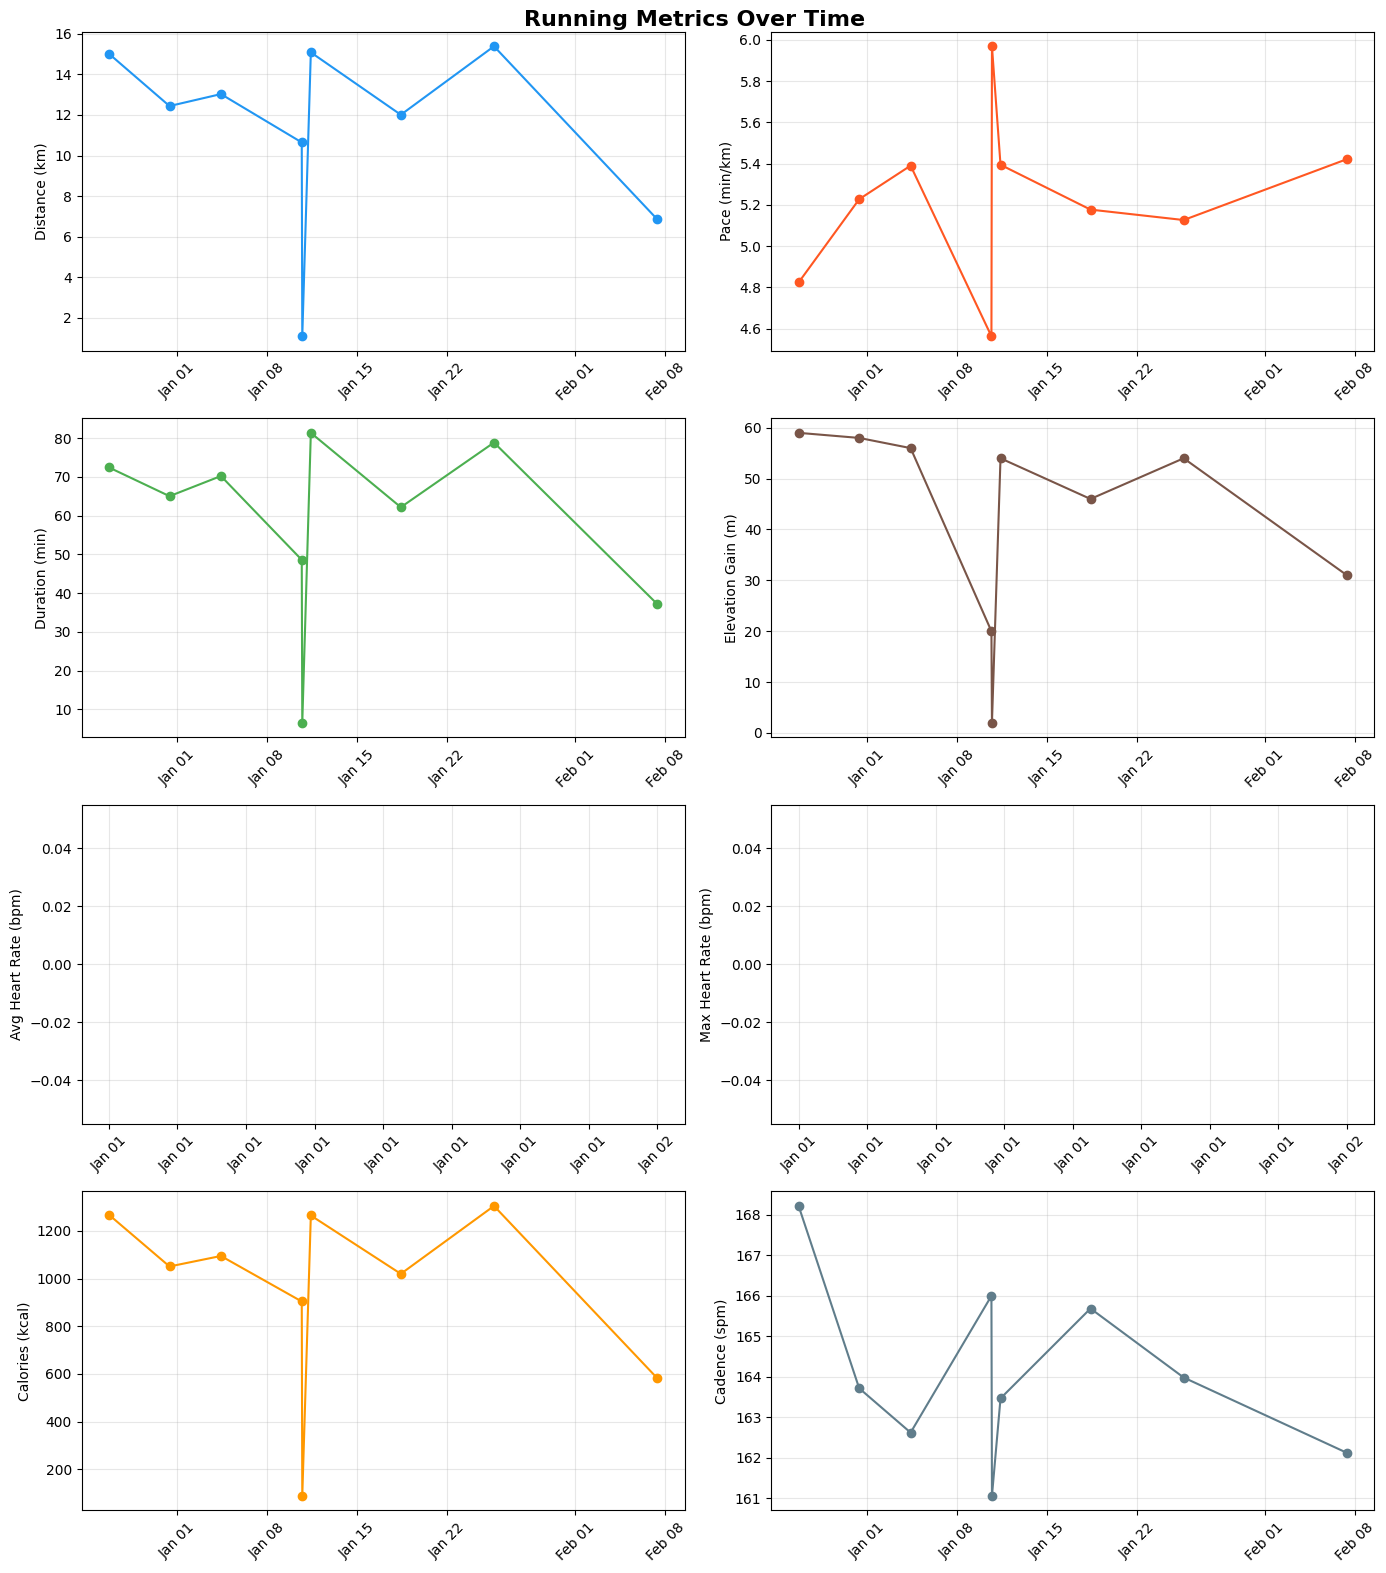

In [2]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
fig.suptitle("Running Metrics Over Time", fontsize=16, fontweight="bold")

date_fmt = mdates.DateFormatter("%b %d")

metrics = [
    ("distance_km", "Distance (km)", "#2196F3"),
    ("pace_min_km", "Pace (min/km)", "#FF5722"),
    ("duration_min", "Duration (min)", "#4CAF50"),
    ("elevation_gain", "Elevation Gain (m)", "#795548"),
    ("avg_hr", "Avg Heart Rate (bpm)", "#E91E63"),
    ("max_hr", "Max Heart Rate (bpm)", "#9C27B0"),
    ("calories", "Calories (kcal)", "#FF9800"),
    ("cadence", "Cadence (spm)", "#607D8B"),
]

for ax, (col, label, color) in zip(axes.flat, metrics):
    data = df.dropna(subset=[col])
    ax.plot(data["start_time"], data[col], "o-", color=color, markersize=6)
    ax.set_ylabel(label)
    ax.xaxis.set_major_formatter(date_fmt)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()